In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:

df = pd.read_csv("Breast Cancer Data.csv") 

print("Dataset Overview:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Dataset Overview:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  are

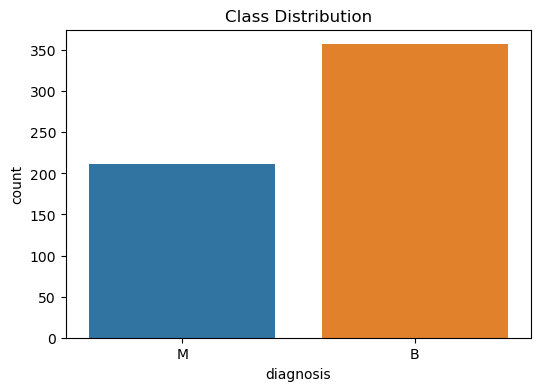

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['diagnosis']) 
plt.title("Class Distribution")
plt.show()

In [12]:

X = df.drop(columns=["diagnosis"]) 
y = df["diagnosis"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



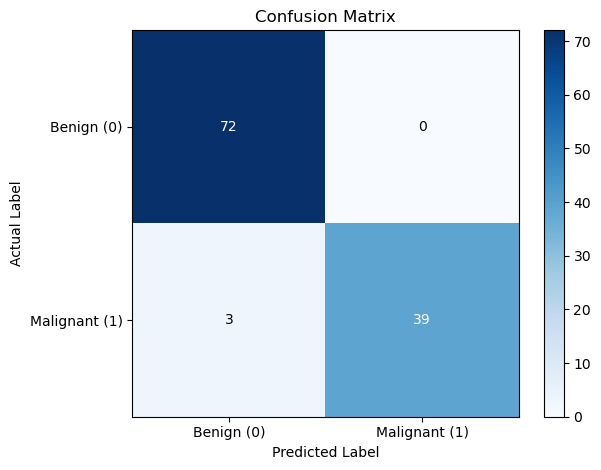

In [6]:

conf_matrix_best = confusion_matrix(y_test, y_pred)

plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix_best.max() / 2.
for i, j in np.ndindex(conf_matrix_best.shape):
    plt.text(j, i, format(conf_matrix_best[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix_best[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()



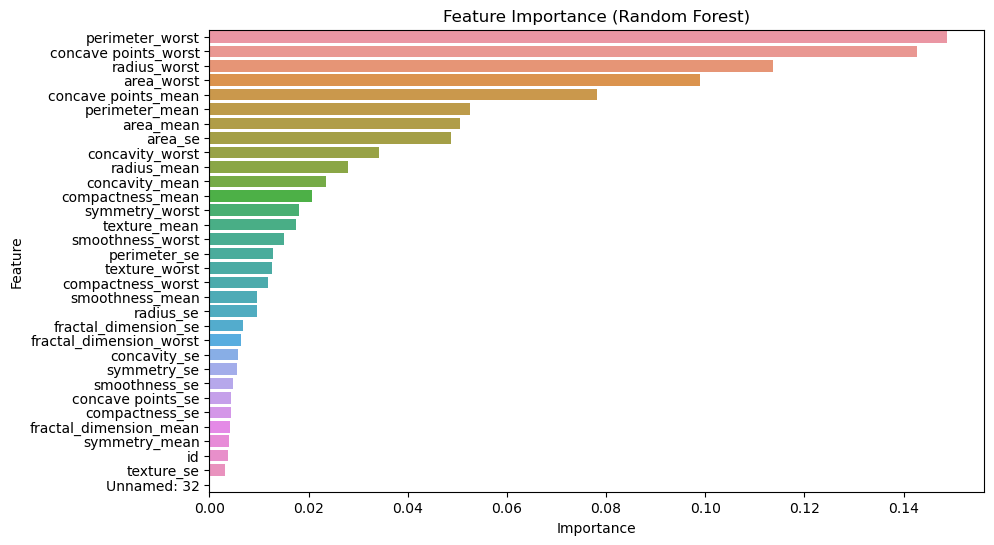

In [13]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [14]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [15]:
print("\nBest Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [16]:
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)


print("\nOptimized Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nOptimized Classification Report:\n", classification_report(y_test, y_pred_best))


Optimized Model Accuracy: 0.956140350877193

Optimized Classification Report:
               precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



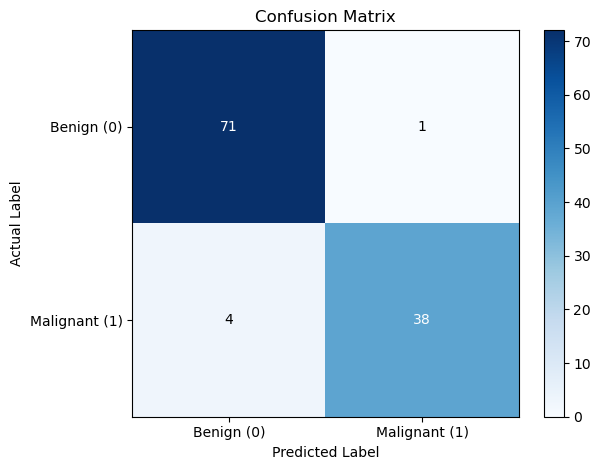

In [18]:

conf_matrix_best = confusion_matrix(y_test, y_pred_best)

plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix_best.max() / 2.
for i, j in np.ndindex(conf_matrix_best.shape):
    plt.text(j, i, format(conf_matrix_best[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix_best[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [23]:
param_grid = {
    'n_estimators': [200, 600, 1000],
    'max_depth': [40, 80, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(rf_model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_


train_accuracy = best_rf_model.score(X_train, y_train)
test_accuracy = best_rf_model.score(X_test, y_test)

print("Best Parameters:", grid_search.best_params_)
print(f"Testing Accuracy: {test_accuracy:.4f}")

y_pred = best_rf_model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
Testing Accuracy: 0.9737

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [24]:
param_grid = {
    'n_estimators': [200, 600, 1000],
    'max_depth': [40, 80, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 3, 4]
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid_search = GridSearchCV(rf_model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_


train_accuracy = best_rf_model.score(X_train, y_train)
test_accuracy = best_rf_model.score(X_test, y_test)

print("Best Parameters:", grid_search.best_params_)
print(f"Testing Accuracy: {test_accuracy:.4f}")

y_pred = best_rf_model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'max_depth': 40, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 1000}
Testing Accuracy: 0.9737

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

